In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [7]:
# Load dataset
data = pd.read_csv("/loan_prediction.csv")

# Handle missing values
for col in data.columns:
    if data[col].dtype == "object":
        data[col].fillna(data[col].mode()[0], inplace=True)
    else:
        data[col].fillna(data[col].median(), inplace=True)

# Encode categorical variables
label_encoders = {}
for col in data.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Features and target
X = data.drop("Loan_Status", axis=1)
y = data["Loan_Status"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


/tmp/ipykernel_895/2337550598.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)
/tmp/ipykernel_895/2337550598.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [8]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_res))


Before SMOTE: [149 342]
After SMOTE: [342 342]


In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    results[name] = (y_test, y_pred, y_prob)



Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.75      0.49      0.59        43
           1       0.77      0.91      0.83        80

    accuracy                           0.76       123
   macro avg       0.76      0.70      0.71       123
weighted avg       0.76      0.76      0.75       123

ROC-AUC: 0.7511627906976744

Random Forest Results:
              precision    recall  f1-score   support

           0       0.71      0.47      0.56        43
           1       0.76      0.90      0.82        80

    accuracy                           0.75       123
   macro avg       0.74      0.68      0.69       123
weighted avg       0.74      0.75      0.73       123

ROC-AUC: 0.7417151162790698


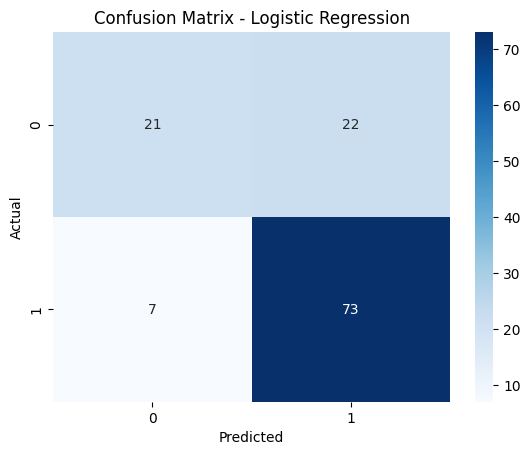

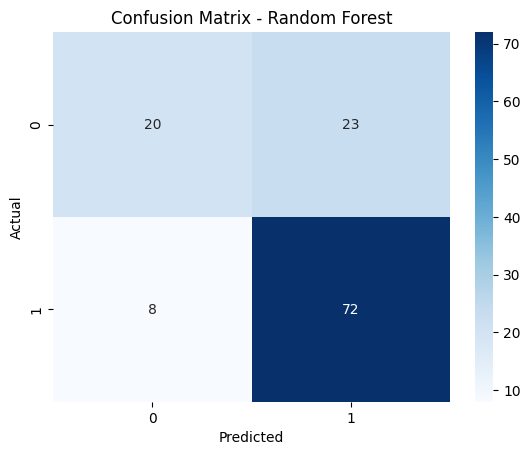

In [10]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

for name, (y_true, y_pred, _) in results.items():
    plot_confusion(y_true, y_pred, name)


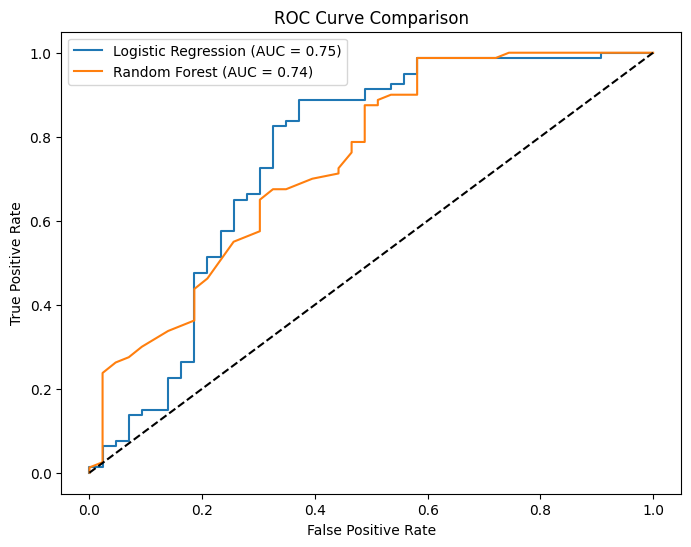

In [11]:
plt.figure(figsize=(8,6))
for name, (y_true, _, y_prob) in results.items():
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr,tpr):.2f})")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


In [12]:
# Logistic Regression coefficients
log_reg = models["Logistic Regression"]
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)
print("\nLogistic Regression Feature Impact:")
print(coefficients)

# Random Forest feature importance
rf = models["Random Forest"]
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)
print("\nRandom Forest Feature Importance:")
print(importances)



Logistic Regression Feature Impact:
              Feature  Coefficient
10     Credit_History     1.331337
2             Married     0.291073
11      Property_Area     0.245004
5       Self_Employed     0.138998
3          Dependents     0.138569
0             Loan_ID     0.132486
9    Loan_Amount_Term     0.076642
6     ApplicantIncome     0.053343
1              Gender    -0.073599
7   CoapplicantIncome    -0.170629
8          LoanAmount    -0.198993
4           Education    -0.205102

Random Forest Feature Importance:
              Feature  Importance
10     Credit_History    0.204698
6     ApplicantIncome    0.134302
0             Loan_ID    0.130518
8          LoanAmount    0.130329
11      Property_Area    0.101387
7   CoapplicantIncome    0.090511
3          Dependents    0.060856
9    Loan_Amount_Term    0.046127
2             Married    0.043430
4           Education    0.024656
5       Self_Employed    0.017415
1              Gender    0.015772
